In [3]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [4]:
df=pd.read_csv("../data/raw/books_raw.csv")
df.head()

,title,category,price,rating,availability,description,upc,num_reviews,product_url
0,It's Only the Himalayas,Travel,£45.17,2,In stock (19 available) In stock In stock In s...,"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...
1,Libertarianism for Beginners,Politics,£51.33,2,In stock (19 available) In stock In stock In s...,Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,£37.59,1,In stock (19 available) In stock In stock In s...,"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...
3,Olio,Poetry,£23.88,1,In stock (19 available) In stock In stock In s...,"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...
4,Our Band Could Be Your Life: Scenes from the A...,Music,£57.25,3,In stock (19 available) In stock In stock In s...,This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   title         221 non-null    str  
 1   category      221 non-null    str  
 2   price         221 non-null    str  
 3   rating        221 non-null    str  
 4   availability  221 non-null    str  
 5   description   220 non-null    str  
 6   upc           221 non-null    str  
 7   num_reviews   221 non-null    str  
 8   product_url   221 non-null    str  
dtypes: str(9)
memory usage: 15.7 KB


In [6]:
print("Total records:", len(df))

Total records: 221


In [7]:
df.isnull().sum()

title           0
category        0
price           0
rating          0
availability    0
description     1
upc             0
num_reviews     0
product_url     0
dtype: int64

In [8]:
print("Duplicate UPCs:", df.duplicated(subset="upc").sum())

Duplicate UPCs: 20


In [9]:
clean_df = df.copy()

Remove Extra Spaces from text columns


In [10]:
text_columns = ["title", "category", "availability", "description"]

for col in text_columns:
    clean_df[col] = clean_df[col].fillna("").str.strip()

Remove Duplicates using UPC(Universal Product Code)

In [11]:
clean_df = clean_df.drop_duplicates(subset="upc")

In [12]:
print("Remaining records:", len(clean_df))
print("Duplicate UPCs:", clean_df.duplicated(subset="upc").sum())

Remaining records: 201
Duplicate UPCs: 0


Handle Missing Descriptions

In [13]:
clean_df["description"] = clean_df["description"].replace("", "No description available")

In [14]:
clean_df["description"].isnull().sum()

np.int64(0)

Convert Price to Numeric and Extract Stock Count

In [15]:
clean_df["price"] = (
    clean_df["price"]
    .str.replace("£", "", regex=False)
    .astype(float)
)

ValueError: could not convert string to float: 'price'

In [16]:
clean_df["price"] = (
    clean_df["price"]
    .str.replace("£", "", regex=False)
)

clean_df["price"] = pd.to_numeric(clean_df["price"], errors="coerce")

In [17]:
clean_df[clean_df["price"].isna()]

,title,category,price,rating,availability,description,upc,num_reviews,product_url
20,title,category,NaN,rating,availability,description,upc,num_reviews,product_url


In [18]:
# Remove duplicated header rows
clean_df = clean_df[clean_df["price"] != "price"]

In [19]:
clean_df[clean_df["price"] == "price"]

,title,category,price,rating,availability,description,upc,num_reviews,product_url


In [20]:
clean_df["price"] = (
    clean_df["price"]
    .str.replace("£", "", regex=False)
)

clean_df["price"] = pd.to_numeric(clean_df["price"])

AttributeError: Can only use .str accessor with string values, not floating

In [21]:
clean_df["price"].dtype

dtype('float64')

In [22]:
clean_df["price"].head(10)

0    45.17
1    51.33
2    37.59
3    23.88
4    57.25
5    35.02
6    52.29
7    17.46
8    20.66
9    13.99
Name: price, dtype: float64

Extract Available Stock Count

In [23]:
clean_df["stock_count"] = (
    clean_df["availability"]
    .str.extract(r"(\d+)")
    .astype(int)
)

ValueError: cannot convert float NaN to integer

In [24]:
clean_df["availability"].unique()

<StringArray>
['In stock (19 available) In stock In stock In stock In stock In stock In stock',
          'In stock (19 available) In stock In stock In stock In stock In stock',
                   'In stock (20 available) In stock In stock In stock In stock',
                            'In stock (20 available) In stock In stock In stock',
                                     'In stock (20 available) In stock In stock',
                                              'In stock (20 available) In stock',
                                                       'In stock (22 available)',
                                                                  'availability',
 'In stock (17 available) In stock In stock In stock In stock In stock In stock',
 'In stock (18 available) In stock In stock In stock In stock In stock In stock',
 'In stock (16 available) In stock In stock In stock In stock In stock In stock',
 'In stock (15 available) In stock In stock In stock In stock In stock In stock']
Le

In [25]:
clean_df["stock_count"] = (
    clean_df["availability"]
    .str.extract(r"\((\d+)\s+available\)", expand=False)
)

clean_df["stock_count"] = pd.to_numeric(
    clean_df["stock_count"],
    errors="coerce"
).fillna(0).astype(int)

In [26]:
clean_df[["availability", "stock_count"]].head(10)

,availability,stock_count
0,In stock (19 available) In stock In stock In s...,19
1,In stock (19 available) In stock In stock In s...,19
2,In stock (19 available) In stock In stock In s...,19
3,In stock (19 available) In stock In stock In s...,19
4,In stock (19 available) In stock In stock In s...,19
5,In stock (19 available) In stock In stock In s...,19
6,In stock (19 available) In stock In stock In s...,19
7,In stock (19 available) In stock In stock In s...,19
8,In stock (19 available) In stock In stock In s...,19
9,In stock (19 available) In stock In stock In s...,19


Feature Extraction

Description Word Count

In [27]:
clean_df["description_word_count"] = clean_df["description"].apply(
    lambda x: len(str(x).split())
)

In [28]:
clean_df[["description", "description_word_count"]].head()

,description,description_word_count
0,"“Wherever you go, whatever you do, just . . . ...",230
1,Libertarianism isn't about winning elections; ...,195
2,"Andrew Barger, award-winning author and engine...",283
3,"Part fact, part fiction, Tyehimba Jess's much ...",249
4,This is the never-before-told story of the mus...,163


Price Band

In [29]:
clean_df["price_band"] = pd.cut(
    clean_df["price"],
    bins=[0, 20, 35, 50, float("inf")],
    labels=["Low", "Medium", "High", "Premium"]
)

In [30]:
clean_df[["price", "price_band"]].head()

,price,price_band
0,45.17,High
1,51.33,Premium
2,37.59,High
3,23.88,Medium
4,57.25,Premium


Affordability Score

In [31]:
clean_df["affordability_score"] = (
    clean_df["price"].max() - clean_df["price"]
)

Value Score

In [32]:
clean_df["value_score"] = (
    clean_df["rating"] / clean_df["price"]
).round(3)

TypeError: unsupported operand type(s) for /: 'str' and 'float'

In [33]:
clean_df["rating"].dtype

<StringDtype(storage='python', na_value=nan)>

In [34]:
clean_df["rating"] = pd.to_numeric(clean_df["rating"], errors="coerce")

In [35]:
clean_df["rating"].isna().sum()

np.int64(1)

In [36]:
clean_df = clean_df.dropna(subset=["rating"]).reset_index(drop=True)

In [37]:
clean_df["rating"].dtype

dtype('float64')

In [38]:
clean_df["value_score"] = (
    clean_df["rating"] / clean_df["price"]
).round(3)

In [39]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   title                   200 non-null    str     
 1   category                200 non-null    str     
 2   price                   200 non-null    float64 
 3   rating                  200 non-null    float64 
 4   availability            200 non-null    str     
 5   description             200 non-null    str     
 6   upc                     200 non-null    str     
 7   num_reviews             200 non-null    str     
 8   product_url             200 non-null    str     
 9   stock_count             200 non-null    int64   
 10  description_word_count  200 non-null    int64   
 11  price_band              200 non-null    category
 12  affordability_score     200 non-null    float64 
 13  value_score             200 non-null    float64 
dtypes: category(1), float64(4), int64(2),

Create Reccommended feature

In [40]:
clean_df["recommended"] = (
    (clean_df["rating"] >= 4) &
    (clean_df["price"] <= clean_df["price"].median())
)

In [41]:
clean_df[["title", "rating", "price", "recommended"]].head()

,title,rating,price,recommended
0,It's Only the Himalayas,2.0,45.17,False
1,Libertarianism for Beginners,2.0,51.33,False
2,Mesaerion: The Best Science Fiction Stories 18...,1.0,37.59,False
3,Olio,1.0,23.88,False
4,Our Band Could Be Your Life: Scenes from the A...,3.0,57.25,False


Save the Cleaned Dataset

In [42]:
clean_df.to_csv("../data/processed/books_cleaned.csv", index=False)

OSError: Cannot save file into a non-existent directory: '..\data\processed'

In [43]:
clean_df.to_csv("../data/cleaned/books_cleaned.csv", index=False)

In [44]:
import os

os.path.exists("../data/processed/books_cleaned.csv")

False

In [45]:
import os

os.path.exists("../data/cleaned/books_cleaned.csv")

True

Plot 1: Price Distribution

plt.figure(figsize=(8,5))

plt.hist(clean_df["price"], bins=15, edgecolor="black")

plt.title("Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")

plt.savefig("../plots/price_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [47]:
import os

os.path.exists("../plots/price_distribution.png")

True

Plot 2: Rating Distribution

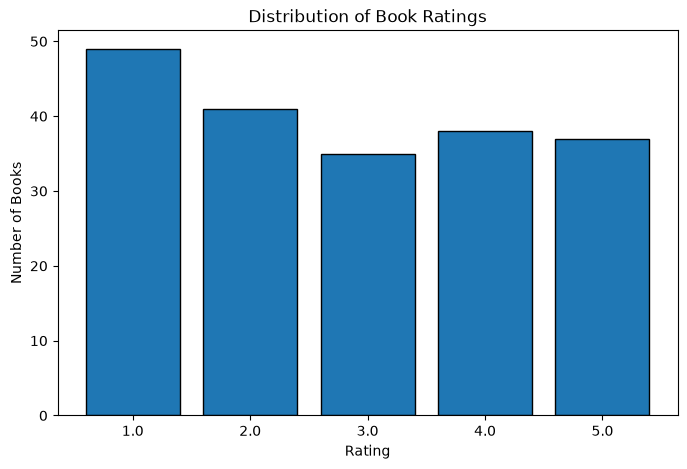

In [48]:
plt.figure(figsize=(8,5))

rating_counts = clean_df["rating"].value_counts().sort_index()

plt.bar(
    rating_counts.index.astype(str),
    rating_counts.values,
    edgecolor="black"
)

plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Books")

plt.savefig("../plots/rating_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Average Price By Category

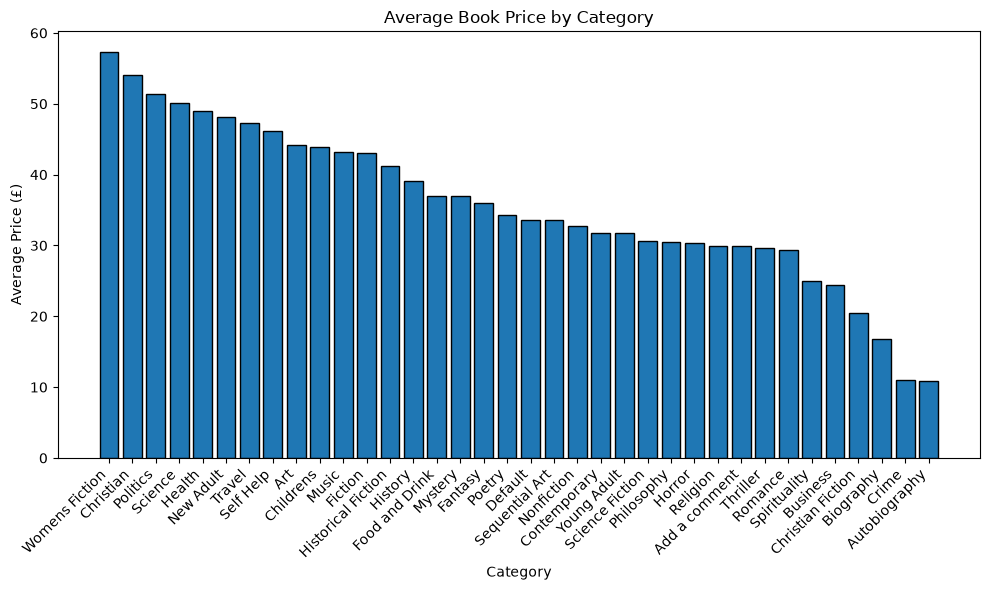

In [49]:
avg_price = (
    clean_df.groupby("category")["price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

plt.bar(
    avg_price.index,
    avg_price.values,
    edgecolor="black"
)

plt.title("Average Book Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Price (£)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig("../plots/average_price_by_category.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Plot 4:Price Vs Rating

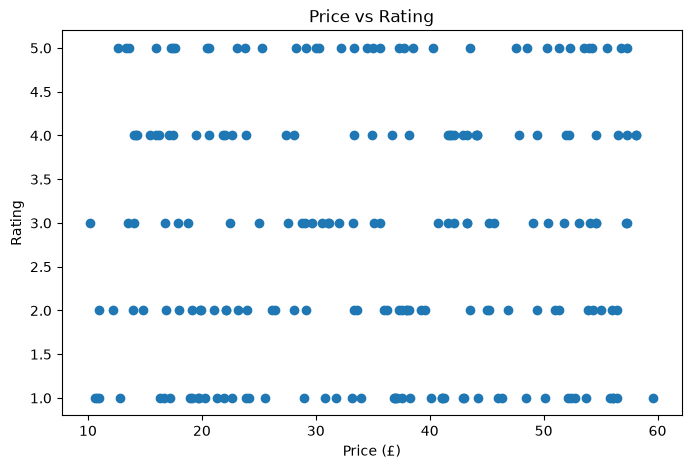

In [50]:
plt.figure(figsize=(8,5))

plt.scatter(
    clean_df["price"],
    clean_df["rating"]
)

plt.title("Price vs Rating")
plt.xlabel("Price (£)")
plt.ylabel("Rating")

plt.savefig("../plots/price_vs_rating.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Plot 5: Word Cloud

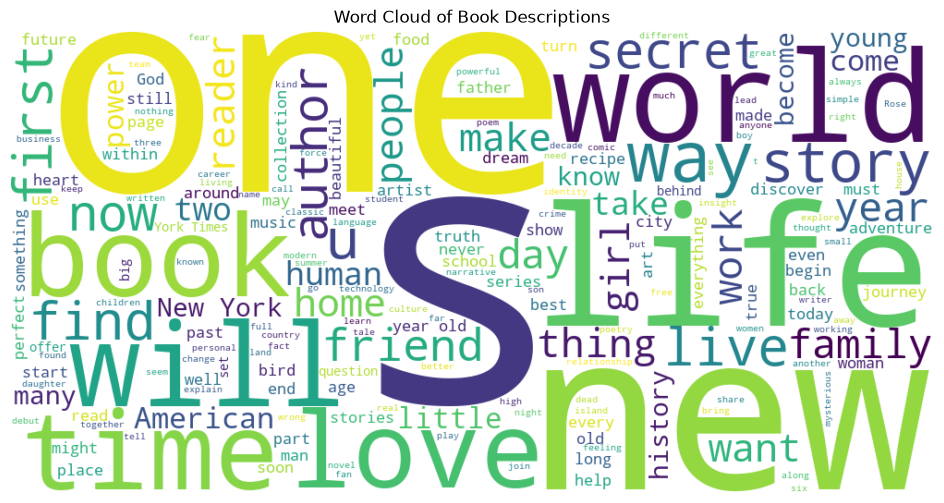

In [51]:
from wordcloud import WordCloud

text = " ".join(clean_df["description"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Book Descriptions")

plt.savefig("../plots/wordcloud.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Elementary Data Analysis

In [52]:
print("Dataset Shape:", clean_df.shape)

print("\nAverage Price: £", round(clean_df["price"].mean(), 2))
print("Median Price: £", round(clean_df["price"].median(), 2))
print("Minimum Price: £", clean_df["price"].min())
print("Maximum Price: £", clean_df["price"].max())

print("\nAverage Rating:", round(clean_df["rating"].mean(), 2))
print("Highest Rating:", clean_df["rating"].max())

Dataset Shape: (200, 15)

Average Price: £ 34.8
Median Price: £ 35.64
Minimum Price: £ 10.16
Maximum Price: £ 59.64

Average Rating: 2.86
Highest Rating: 5.0


In [53]:
clean_df["rating"].value_counts().sort_index()

rating
1.0    49
2.0    41
3.0    35
4.0    38
5.0    37
Name: count, dtype: int64

In [54]:
   clean_df["category"].value_counts()

category
Default               31
Sequential Art        23
Nonfiction            20
Young Adult           10
Fantasy               10
Poetry                 9
Fiction                9
Romance                9
Food and Drink         9
Add a comment          7
Science Fiction        5
History                5
Mystery                5
Historical Fiction     5
Childrens              5
Business               4
Music                  3
Thriller               3
Philosophy             3
New Adult              3
Travel                 2
Spirituality           2
Horror                 2
Self Help              2
Religion               2
Science                2
Politics               1
Art                    1
Contemporary           1
Health                 1
Crime                  1
Christian              1
Christian Fiction      1
Womens Fiction         1
Biography              1
Autobiography          1
Name: count, dtype: int64

In [55]:
clean_df.groupby("category")["price"].mean().sort_values(ascending=False)

category
Womens Fiction        57.360000
Christian             54.000000
Politics              51.330000
Science               50.160000
Health                49.050000
New Adult             48.070000
Travel                47.300000
Self Help             46.190000
Art                   44.180000
Childrens             43.842000
Music                 43.196667
Fiction               43.048889
Historical Fiction    41.232000
History               39.080000
Food and Drink        36.975556
Mystery               36.938000
Fantasy               35.962000
Poetry                34.323333
Default               33.561935
Sequential Art        33.524783
Nonfiction            32.690000
Contemporary          31.770000
Young Adult           31.751000
Science Fiction       30.666000
Philosophy            30.496667
Horror                30.305000
Religion              29.920000
Add a comment         29.861429
Thriller              29.626667
Romance               29.295556
Spirituality          24.950000

In [56]:
clean_df["recommended"].value_counts()

recommended
False    162
True      38
Name: count, dtype: int64

Analysis 1: Out of 200 Books, only 38 were reccomended which suggests that only a small amount of books offer a combination of high ratings and affordable prices

Analysis 2: The Category based Average price analysis suggests that categories such as women fiction, christian etc. have the highest average price while autobiography and crime have lowest average price which can help online bookstores to decide on pricing and discounts

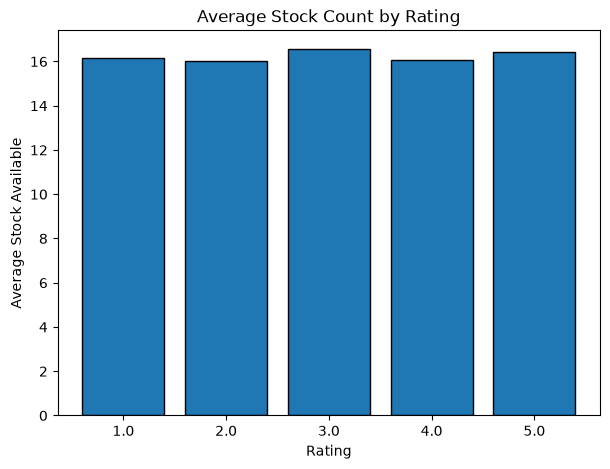

In [57]:
stock_by_rating = clean_df.groupby("rating")["stock_count"].mean()

plt.figure(figsize=(7,5))

plt.bar(
    stock_by_rating.index.astype(str),
    stock_by_rating.values,
    edgecolor="black"
)

plt.title("Average Stock Count by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Stock Available")

plt.show()

Analysis 3: As per Average Stock Vs Rating graph it concludes that stock is not maintained as per rating which can be improved by clearing the stock of lower rated books or offering discounts on them

Analysis 4: The Price Distribution Graph Suggests that the online bookstore consist of affordable books with price as low as 10 pounds and premium books with price as high as 60 pounds